# 🔁 01-数据结构与算法 · 主题 7：回溯（DFS + 撤销）

> 回溯 = **穷举所有可能的分支** + **不满足就回退（撤销）**。处理排列、组合、子集、棋盘类问题的标准框架。
> 本 notebook 目标：**背熟回溯模板 → 掌握三种去重/剪枝姿势 → 吃透 9 道高频题 → 通过 25 道自测**。

**前置**：主题 6（递归/DFS）。**运行环境**：Python 3.8+，无第三方依赖。

## 核心概念

### (a) 🗂️ 回溯：决策树心智、通用模板与去重剪枝

回溯 = 穷举所有可能的分支 + 不满足就回退（撤销），是排列、组合、子集、棋盘类问题的标准框架。本 notebook 背熟回溯模板，掌握去重与剪枝，精讲 9 道高频题。

```mermaid
flowchart TB
    N1["🔁 回溯心智模型：决策树"] --> N2["通用模板：path + 选择 + 撤销"]
    N2 --> N3["子集 78 / 组合 77"]
    N2 --> N4["组合总和 39：剪枝"]
    N2 --> N5["全排列 46/47：去重核心考点"]
    N4 --> N6["括号生成 22：约束剪枝"]
    N5 --> N7["网格题：单词搜索 79 / N 皇后 51"]
    N6 --> N8["剪枝技巧汇总"]
    N7 --> N8
    N8 --> N9["复杂度直觉与自测"]
```

- **N1 · 回溯心智模型**：把每个阶段的"选择"画成一棵树，回溯就是深度优先地走完整棵树，走到头或不符合就回头换一条路——所以它本质是 DFS + 状态撤销。
- **N2 · 通用模板**：四步：选（加入 path）→ 递归 → 撤销（弹出 path）→ 换下一个选择。写题前先默写模板，再套题目条件，就能稳拿大部分回溯题。
- **N3 · 子集与组合**：子集 78 是每个元素"选/不选"两条分支；组合 77 用"开始下标"控制不回头看，保证组合不重复——两者结构同源。
- **N4 · 组合总和 39**：允许重复取元素，排序后按"当前和 + 剩余容量"剪枝，能把指数级搜索砍掉一大半，是"回溯 + 剪枝"的标准示范。
- **N5 · 全排列与去重**：全排列要记录"哪些位置已用"；含重复元素的 47 是核心考点——同层去重（排序 + used 数组）只保留第一个相同元素。
- **N6 · 括号生成 22**：用"左括号数 < n 可加左、右括号数 < 左括号数可加右"两个约束剪枝，保证任何时候右括号不超左括号，输出就是合法的括号串。
- **N7 · 网格题**：单词搜索是网格 DFS + 回溯（走过的格子标记再还原）；N 皇后用"列 + 两条对角线"判冲突，回溯逐行放皇后。
- **N8 · 剪枝技巧汇总**：排序去重、提前判可行性、对称性剪枝、记忆化——面试能主动说出剪枝思路是明显的加分项。
- **N9 · 复杂度直觉与自测**：回溯一般指数级（O(分支^深度)），回答面试时要说"最坏情况 + 剪枝后的实际表现"，再用 L1/L2/L3 自测清单收尾。

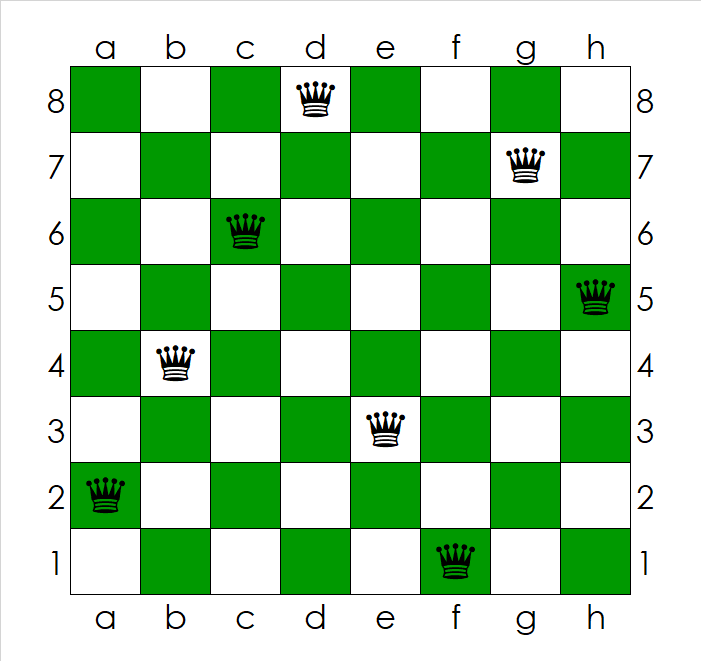

> 📷 8 皇后问题的一个解（每行/列/斜线至多一个皇后）
> *图源：Wikimedia Commons（开放授权）*


## §1 心智模型：决策树

回溯问题都可以画成一棵**决策树**：

- **节点** = 当前已选择的部分解（path）
- **边** = 每一步的可选动作（choices）
- **叶子** = 完整解（记录）或死路（剪掉）

```
            root
         /   |    \
        1    2     3        <- 第一层选择
       / \   / \
      2   3 1   3 ...       <- 第二层选择
```

回溯 vs 普通递归：回溯在递归返回后要**撤销现场**（状态回滚），让兄弟分支从相同起点出发。

### 复杂度直觉（背下来）

| 问题 | 状态数 | 每状态成本 | 总复杂度 |
|------|--------|-----------|---------|
| 子集（是否取每个元素） | $2^n$ | $O(n)$ | $O(n \cdot 2^n)$ |
| 组合 $C(n,k)$ | $\binom{n}{k}$ | $O(k)$ | $O(k \cdot \binom{n}{k})$ |
| 全排列 | $n!$ | $O(n)$ | $O(n \cdot n!)$ |
| N 皇后 | $\approx \binom{n^2}{n}$ | $O(n)$ | 指数级，剪枝后大幅缩小 |

## §2 通用模板（背熟，写题前先默写）

```python
def backtrack(path, choices):
    if 满足结束条件:
        记录解(path)
        return
    for 每个可选动作 c in choices:
        if 不合法(c):
            continue          # 剪枝：放弃这一支
        做选择(c)             # 状态前进
        backtrack(path, choices)
        撤销选择(c)           # 状态回滚（回溯的灵魂）
```

**四要素**：路径（path）、选择列表（choices）、结束条件、剪枝条件。

> ⚠️ **撤销必须对称**：做了 `path.append(x)` 就必须 `path.pop()`；修改了计数器/集合也必须回滚，否则兄弟分支被污染。

## §3 子集（LeetCode 78）

**题目**：返回所有子集（含空集与自身），共 $2^n$ 个。

**思路**：对每个元素**选或不选**两条分支；用 `start` 下标保证不回头（不产生重复子集）。

**为什么用 `start`**：子集无序——选了 1 后再也不能选 <1 的刻场景，避免 `[1,2]` 与 `[2,1]` 重复。

**复杂度**：$O(n \cdot 2^n)$ 时间，$O(n)$ 递归深度（不含结果空间）。

> 💡 对照：二进制枚举 `for mask in range(1 << n)` 等价，第 $i$ 位为 1 表示选 $nums[i]$。

In [1]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------
# ================= 回溯经典题 78：子集 =================
# 【题目目标】返回数组 nums 的全部子集（含空集与自身），共 2^n 个；输出顺序不限
# 【算法思路】回溯 = DFS + 状态撤销：对每个元素「选/不选」两条分支；用起点下标
#            start 保证「只往后选」，避免 [1,2] 与 [2,1] 这类重复（子集无序）
# 【变量含义】nums：输入数组；res：结果列表；path：当前正在构造的子集；
#            start：本层可选的起始下标，只允许选 start 及之后的元素
# 【循环不变量】path 中元素在原数组中的下标严格递增 → 每个子集只会被构造一次
# 【递归终止】无显式终止条件：每进入一层 backtrack，当前 path 就是一个合法子集，
#            先记录；for 循环穷尽 start..len(nums)-1 后自然返回（叶子 = 记录时刻）
# 【关键边界】res.append(path[:]) 必须用拷贝，直接 append(path) 存的是引用，后续
#            pop 会污染已记录结果；空数组输入返回 [[]]；递归传 i+1 保证不回头
# 【复杂度】时间 O(n·2^n)：2^n 个节点 × 每节点拷贝 path 成本 O(n)；
#          空间 O(n)：递归栈深度（不含结果占用的空间）
# 78. 子集：每个元素「选或不选」两条分支，共生成 2^n 个子集
# start 保证只往后选，避免 [1,2] 与 [2,1] 这类重复
def subsets(nums):
    # res 用来保存所有找到的子集
    res = []                # 存放结果的列表

    def backtrack(start, path):   # 回溯：start 起点，path 当前路径
        """
        回溯函数
        :param start: 遍历开始下标，保证只选start之后的元素，避免 [1,2] 和 [2,1] 这种重复子集
        :param path: 当前正在构建的子集（路径）
        """
        # path[:] 是path的拷贝！！
        # 直接append(path)会存引用，后面pop修改path的时候res里内容会跟着变
        # 每进入一层回溯，当前path就是一个合法子集，直接加入结果
        res.append(path[:])             # 每进入一层，当前路径就是一个合法子集

        # 从start开始循环，依次选取元素
        for i in range(start, len(nums)):   # 依次尝试候选元素
            print(f"第{i}次")
            # 选择：把nums[i]加入当前路径
            path.append(nums[i])   # 选择：把 nums[i] 加入当前路径
            # 递归，下一轮只能选 i+1 后面的数，不能回头选前面的，防止重复
            backtrack(i + 1, path)   # 递归：下一轮只能从 i+1 之后选（防回头）
            # 撤销选择（回溯核心！）：递归返回后，删掉刚才加的元素，尝试下一个分支
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）

    # 启动回溯：从下标0开始，初始路径是空列表
    backtrack(0, [])            # 从下标 0、空路径开始搜索
    return res               # 返回结果


print('subsets([1,2,3]):')
for s in subsets([1, 2, 3,5,6]):
    print(' ', s)
# 3个元素，子集总数2^3=8个
print('个数 =', len(subsets([1, 2, 3])))
# 空数组，只有空集这1个子集
print('subsets([]) =', subsets([]))


subsets([1,2,3]):
第0次
第1次
第2次
第3次
第4次
第4次
第3次
第4次
第4次
第2次
第3次
第4次
第4次
第3次
第4次
第4次
第1次
第2次
第3次
第4次
第4次
第3次
第4次
第4次
第2次
第3次
第4次
第4次
第3次
第4次
第4次
  []
  [1]
  [1, 2]
  [1, 2, 3]
  [1, 2, 3, 5]
  [1, 2, 3, 5, 6]
  [1, 2, 3, 6]
  [1, 2, 5]
  [1, 2, 5, 6]
  [1, 2, 6]
  [1, 3]
  [1, 3, 5]
  [1, 3, 5, 6]
  [1, 3, 6]
  [1, 5]
  [1, 5, 6]
  [1, 6]
  [2]
  [2, 3]
  [2, 3, 5]
  [2, 3, 5, 6]
  [2, 3, 6]
  [2, 5]
  [2, 5, 6]
  [2, 6]
  [3]
  [3, 5]
  [3, 5, 6]
  [3, 6]
  [5]
  [5, 6]
  [6]
第0次
第1次
第2次
第2次
第1次
第2次
第2次
个数 = 8
subsets([]) = [[]]


## §4 组合 / 组合总和（带剪枝）

### 77 组合：从 n 取 k

**剪枝公式**：当「剩余可选数 < 还需要的数」时停止：

$$\text{还需要的数} = k - len(path), \quad \text{剩余可选} = n - i + 1$$

$$\text{剪枝条件: } n - i + 1 < k - len(path) \implies \text{break}$$

### 39 组合总和（元素可重复使用）

**题目**：候选可无限使用、和等于 target 的组合。

**剪枝**：先排序，`sum > target` 剪掉；`i` 不从 `start+1` 而从 `start` 开始（允许重复选自己）。

```python
def backtrack(start, path, total):
    if total == target: res.append(path[:]); return
    for i in range(start, len(candidates)):
        if total + candidates[i] > target: break   # 排序后剪枝
        path.append(candidates[i])
        backtrack(i, path, total + candidates[i])   # 注意 i 不是 i+1
        path.pop()
```

In [2]:
# ================= 组合 77 / 组合总和 39（回溯 + 剪枝） =================
# 【题目目标】77：从 1..n 中选 k 个数组成组合（无序）；39：候选可无限重复使用，
#            找出所有和为 target 的组合
# 【算法思路】回溯 + 剪枝。组合无序 → start 起点防回头；77 按「剩余可选数 < 还需要的
#            数」剪枝；39 先排序，total + candidates[i] > target 时直接 break
#            （已排序，后面的值只会更大，整层全剪）
# 【变量含义】n/k：范围与个数；res：结果列表；path：当前组合；start：起始下标；
#            total：当前组合的元素和；i：候选下标
# 【递归终止】77：len(path)==k 时记录组合并返回；39：total==target 时记录并返回
# 【循环不变量】path 中候选下标严格递增（组合不重复）；39 中 total 单调不减，
#            配合排序剪枝保证不漏解也不重复
# 【关键边界】77 剪枝条件 n-i+1 < k-len(path) 在循环体内 break；39 递归必须传 i
#            （不是 i+1）才能重复选取同一个元素；39 使用前必须先排序
# 【复杂度】77：O(k·C(n,k))；39：最坏指数级，排序 + 剪枝后大幅缩小；
#          空间均为递归深度 O(k) / O(target)
# 77. 组合：从 1..n 中选 k 个数，组合无序 -> 用 start 防回头
# 剪枝：剩余可选数 n-i+1 小于还需要的 k-len(path) 时直接停止
def combine(n, k):
    res = []                # 存放结果的列表
    def backtrack(start, path):   # 回溯：start 起点，path 当前路径
        if len(path) == k:   # 已选满 k 个数：记录一个组合
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for i in range(start, n + 1):  # 依次尝试当前可选的数
            if n - i + 1 < k - len(path):   # 剪枝：剩余数不够
                break
            path.append(i)      # 选择：把 i 加入当前组合
            backtrack(i + 1, path)   # 递归：下一轮只能从 i+1 之后选（防回头）
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
    backtrack(1, [])            # 从 1 开始选，初始路径为空
    return res               # 返回结果

print('combine(4,2) =', combine(4, 2))   # 期望 [[1,2],[1,3],[1,4],[2,3],[2,4],[3,4]]
print('个数 =', len(combine(4, 2)))       # 期望 6 = C(4,2)

# 39. 组合总和：candidates 可无限重复使用，找所有和为 target 的组合
# 先排序 + 前缀和剪枝：total + candidates[i] > target 时，后面的更大，直接 break
def combination_sum(candidates, target):
    candidates.sort()            # 排序：为剪枝做准备（后面的值只会更大）
    res = []                # 存放结果的列表
    def backtrack(start, path, total):   # 回溯：start 起点，path 当前组合，total 当前和
        if total == target:     # 和正好等于 target：记录一个解
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for i in range(start, len(candidates)):  # 从 start 开始枚举（组合防回头）
            if total + candidates[i] > target:  # 加上当前值就超 target
                break                   # 已排序：后面的更大，全剪
            path.append(candidates[i])  # 选择该元素
            backtrack(i, path, total + candidates[i])   # i 可复用
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
    backtrack(0, [], 0)        # 从下标 0、空路径、和为 0 开始
    return res               # 返回结果

print('combination_sum([2,3,6,7],7) =', combination_sum([2, 3, 6, 7], 7))  # [[2,2,3],[7]]
print('combination_sum([2,3,5],8) =', combination_sum([2, 3, 5], 8))      # [[2,2,2,2],[2,3,3],[3,5]]

combine(4,2) = [[1, 2], [1, 3], [1, 4], [2, 3], [2, 4], [3, 4]]
个数 = 6
combination_sum([2,3,6,7],7) = [[2, 2, 3], [7]]
combination_sum([2,3,5],8) = [[2, 2, 2, 2], [2, 3, 3], [3, 5]]


## §5 全排列（46）与去重（47）——核心考点

### 46 全排列

**区别**：排列**有序**，每次都要从整个数组里选（不用 start），用 `used` 数组标记已用元素。

**复杂度**：$n!$ 个叶子，总 $O(n \cdot n!)$。

### 47 全排列 II（含重复元素，去重）

**去重剪枝**（背下来）：先排序，然后在同一层跳过重复值：

$$\text{剪枝: } i > 0 \land nums[i] == nums[i-1] \land \text{not } used[i-1]$$

**为什么 `not used[i-1]`**：`used[i-1]` 为 True 说明上一个相同值已在**当前路径**（不同层，允许）；为 False 说明它刚被撤销（**同一层**，会重复，剪掉）。

> 💡 这个条件等价于「同一层相同值只取第一个」——面试官最爱追问。

In [3]:
# ============== 全排列 46 / 全排列 II 47（核心去重考点） ==============
# 【题目目标】46：返回 nums 的全部排列（顺序敏感，共 n! 个）；47：nums 含重复
#            元素时输出去重后的全部排列（3!/2! 个）
# 【算法思路】回溯 + used 标记：排列有序，每层都要从整个数组里选（不用 start）；
#            47 先排序，再用「同层去重」剪枝跳过重复值
# 【变量含义】nums：输入数组；res：结果列表；used[i]：nums[i] 是否已在当前路径；
#            path：当前已排好的前缀
# 【递归终止】len(path)==len(nums) 时记录一个完整排列并返回
# 【循环不变量】used 与 path 严格同步：每一层对每个「未使用」元素恰好尝试一次
# 【关键边界】47 去重条件 i>0 and nums[i]==nums[i-1] and not used[i-1]：used[i-1]
#            为 True 表示上一相同值在「当前路径上」（不同层，允许）；为 False 表示
#            它刚被撤销（同一层兄弟，剪掉）——同一层相同值只取第一个；
#            used 必须与 path 成对 add/remove，否则兄弟分支被污染
# 【复杂度】46：O(n·n!)（n! 个叶子 × 每层复制 O(n)）；47：去重后 ≤ n!；
#          空间 O(n)（used + 递归栈）
# 46. 全排列：排列有序，每层都要从整个数组里选（不用 start），用 used 标记已用元素
def permute(nums):
    res = []                # 存放结果的列表
    used = [False] * len(nums)    # used[i] 标记 nums[i] 是否已用在当前路径
    def backtrack(path):       # path 是当前已排好的前缀
        if len(path) == len(nums):  # 排列长度已满：记录一个完整排列
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for i in range(len(nums)):  # 排列有序：每层都从整个数组里选
            if used[i]:            # 该位置已用，跳过
                continue        # 剪枝：跳过该分支
            used[i] = True         # 标记已用
            path.append(nums[i])   # 选择：把 nums[i] 加入当前路径
            backtrack(path)        # 递归放下一层
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
            used[i] = False        # 撤销标记
    backtrack([])               # 从空前缀开始
    return res               # 返回结果

print('permute([1,2,3]) =', permute([1, 2, 3]))  # 打印全部排列
print('个数 =', len(permute([1, 2, 3])))    # 期望 6 = 3!

# 47. 全排列 II（含重复元素）：排序 + 同层去重
# 去重条件：i>0 且 nums[i]==nums[i-1] 且 not used[i-1]——同一层相同值只取第一个
def permute_unique(nums):
    nums.sort()                 # 排序：让相同值相邻，便于去重
    res = []                # 存放结果的列表
    used = [False] * len(nums)    # used[i] 标记 nums[i] 是否已用在当前路径
    def backtrack(path):       # path 是当前已排好的前缀
        if len(path) == len(nums):  # 排列长度已满：记录一个完整排列
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for i in range(len(nums)):  # 排列有序：每层都从整个数组里选
            if used[i]:            # 该位置已用，跳过
                continue        # 剪枝：跳过该分支
            if i > 0 and nums[i] == nums[i - 1] and not used[i - 1]:  # 同层去重核心剪枝
                continue                  # 同一层去重剪枝
            used[i] = True         # 标记已用
            path.append(nums[i])   # 选择：把 nums[i] 加入当前路径
            backtrack(path)        # 递归放下一层
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
            used[i] = False        # 撤销标记
    backtrack([])               # 从空前缀开始
    return res               # 返回结果

print('permute_unique([1,1,2]) =', permute_unique([1, 1, 2]))  # 期望 3 种
print('个数 =', len(permute_unique([1, 1, 2])))   # 期望 3 = 3!/2!

permute([1,2,3]) = [[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]
个数 = 6
permute_unique([1,1,2]) = [[1, 1, 2], [1, 2, 1], [2, 1, 1]]
个数 = 3


### 同层去重 vs 同路径去重（47 / 40 / 90）

**两类去重场景**：

| | 同路径去重 | 同层去重 |
|---|---|---|
| 问题 | 47 全排列 II | 40 组合总和 II、90 子集 II |
| 手段 | `used` 数组 | 排序 + 同层剪枝 |
| 写法 | `i > 0 and nums[i] == nums[i-1] and not used[i-1]` | `i > start and candidates[i] == candidates[i-1]` |
| 剪枝对象 | 同**一层**的兄弟分支（但依赖 used 标记路径） | 同**一层**的兄弟分支 |

**对比两种写法**：

- `not used[i-1]`（47 排列）：`used[i-1] == True` 表示 `nums[i-1]` 正在**当前路径**上使用（不同层的重复，允许）；`used[i-1] == False` 表示它刚被撤销，说明 `nums[i]` 与它是**同一层**的兄弟，剪掉。
- `i > start`（40/90 组合/子集）：`i == start` 表示 `nums[i]` 是**本层第一个**可选值，即使和前一个相同也不能剪（它代表新的一组）；`i > start` 且与前一个相等，说明前一个相同值已在**同一层**处理过，继续选必产生重复结果。

**何时用哪种**：

- **排列**（每个位置都要从整个数组选，顺序敏感）→ `used` 数组标记**路径上**的元素（同路径去重）；
- **组合 / 子集**（从 `start` 往后选，顺序不敏感）→ 排序后用 `i > start` 在同一**层**跳过重复值（同层去重）。

> 💡 记忆点：`used` 管「这一条路」，`i > start` 管「这一层」。

In [4]:
# ============== 组合总和 II 40（排序 + 同层去重 + 剪枝） ==============
# 【题目目标】candidates 含重复值且每个元素最多用一次，找出所有和为 target
#            的不重复组合
# 【算法思路】排序 + 同层去重 + 前缀和剪枝：与 39 的差别是递归传 i+1（每个元素
#            只用一次），且同一层跳过重复值
# 【变量含义】candidates：候选数组（已排序）；target：目标和；res：结果列表；
#            path：当前组合；total：当前和；start：本层起始下标；i：候选下标
# 【递归终止】total==target 时记录组合并返回
# 【循环不变量】path 中下标严格递增（组合不重复）；同一层相同值只取第一个
# 【关键边界】去重条件必须写 i>start and candidates[i]==candidates[i-1]：i==start
#            是本层第一个可选值，即使与前一个相同也不能剪（代表新的一组）；
#            排序后 total+candidates[i]>target 可 break（后面更大）；递归 i+1
# 【复杂度】最坏 O(2^n)（去重 + 剪枝后实际远小于上界），空间 O(target)
# 40. 组合总和 II：每个元素只能用一次，且 candidates 含重复值
# 排序 + 同层去重（i>start 且与前一个相同则跳过）+ 前缀和剪枝
def combination_sum2(candidates, target):
    """40 组合总和 II：每个元素只能用一次，candidates 含重复 → 排序 + 同层去重"""
    candidates.sort()                       # 排序：让相同值相邻，便于去重 + 剪枝
    res = []                # 存放结果的列表
    def backtrack(start, path, total):   # 回溯：start 起点，path 当前组合，total 当前和
        if total == target:     # 和正好等于 target：记录一个解
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for i in range(start, len(candidates)):  # 从 start 开始枚举（组合防回头）
            if total + candidates[i] > target:  # 加上当前值就超 target
                break                       # 排序后：后面更大，整层剪枝
            if i > start and candidates[i] == candidates[i - 1]:  # 同层去重：重复值只取第一个
                continue                    # 同层去重：重复值只取本层第一个
            path.append(candidates[i])  # 选择该元素
            backtrack(i + 1, path, total + candidates[i])   # 每个元素只用一次 -> i+1
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
    backtrack(0, [], 0)        # 从下标 0、空路径、和为 0 开始
    return res               # 返回结果

# 测试辅助函数：把结果规范化（每个组合排序 + 整体排序）再做集合比较
def norm(res):
    return sorted(sorted(x) for x in res)   # 集合比较：内容排序 + 外层排序

assert norm(combination_sum2([10, 1, 2, 7, 6, 1, 5], 8)) == norm([[1, 1, 6], [1, 2, 5], [1, 7], [2, 6]])
assert norm(combination_sum2([2, 5, 2, 1, 2], 5)) == norm([[1, 2, 2], [5]])
print('combination_sum2 测试通过 ✓')

combination_sum2 测试通过 ✓


In [5]:
# ================= 子集 II 90（排序 + 同层去重） =================
# 【题目目标】nums 含重复元素，输出所有不重复子集（78 的含重复版本）
# 【算法思路】排序 + 同层去重 + 回溯：每个节点（进入 backtrack 时）都是一个子集，
#            直接记录；for 循环里跳过同一层的重复值
# 【变量含义】nums：输入数组（已排序）；res：结果列表；path：当前子集；
#            start：本层起始下标；i：候选下标
# 【递归终止】无显式终止条件：每进入一层即记录当前子集，for 穷尽后自然返回
# 【循环不变量】path 下标严格递增，且同一层相同值只取第一个 → 不产生重复子集
# 【关键边界】去重条件 i>start and nums[i]==nums[i-1]：i==start 表示本层第一个
#            可选值，即使与前一个相等也要取（代表新的一组）；每层节点都记录
#            （包括空集与完整集）
# 【复杂度】最坏 O(n·2^n)（去重后实际更少），空间 O(n)
# 90. 子集 II：数组含重复元素，排序 + 同层去重，输出所有不重复子集
def subsets_with_dup(nums):
    """90 子集 II：含重复元素，排序 + 同层去重，输出所有不重复子集"""
    nums.sort()                             # 排序：相同值相邻
    res = []                # 存放结果的列表
    def backtrack(start, path):   # 回溯：start 起点，path 当前路径
        res.append(path[:])                 # 每个节点都是一个子集
        for i in range(start, len(nums)):   # 依次尝试候选元素
            if i > start and nums[i] == nums[i - 1]:   # 同层去重：重复值只取第一个
                continue                    # 同层去重：跳过重复值
            path.append(nums[i])   # 选择：把 nums[i] 加入当前路径
            backtrack(i + 1, path)   # 递归：下一轮只能从 i+1 之后选（防回头）
            path.pop()            # 撤销选择：尝试完这个分支后回退（回溯核心）
    backtrack(0, [])            # 从下标 0、空路径开始搜索
    return res               # 返回结果

assert sorted(sorted(s) for s in subsets_with_dup([1, 2, 2])) == sorted(sorted(s) for s in [[], [1], [1, 2], [1, 2, 2], [2], [2, 2]])
print('subsets_with_dup 测试通过 ✓')

subsets_with_dup 测试通过 ✓


In [6]:
# ================= 分割回文串 131（切割类模板） =================
# 【题目目标】把字符串 s 切成若干段，每段都是回文子串，返回所有切分方案
# 【算法思路】切割类回溯：start 是当前切割起点，枚举 end 作为切割点；只有
#            s[start..end] 是回文才切下来，然后从 end+1 继续切剩余部分
# 【变量含义】s：输入字符串；res：结果列表；path：已切下的回文段列表；
#            start：下一段的起点；end：本段终点；is_pal(lo,hi)：双指针判断
#            s[lo..hi] 是否为回文
# 【递归终止】start==len(s) 表示切到末尾，记录一种完整分割方案
# 【循环不变量】path 中各段按原序拼接恰好覆盖 s[0:start]（切下的段无缝衔接）
# 【关键边界】必须 s[start..end] 是回文才切；递归从 end+1 继续，保证每段至少
#            一个字符；is_pal 用双指针 O(n) 判断
# 【复杂度】最坏 O(n·2^n)（每个字符可切/可不切），空间 O(n)
# 131. 分割回文串：切割类回溯——start 是当前切割起点，枚举 end 作为切割点
# 只有 s[start..end] 是回文才切下来，然后从 end+1 继续切
def partition(s):
    """131 分割回文串：切割类模板 —— start 是切割起点，end 从 start..n-1 枚举切割点"""
    def is_pal(lo, hi):                     # 双指针判断 s[lo..hi] 是否回文
        while lo < hi:
            if s[lo] != s[hi]:
                return False
            lo, hi = lo + 1, hi - 1
        return True

    res = []                # 存放结果的列表
    def backtrack(start, path):   # 回溯：start 起点，path 当前路径
        if start == len(s):                 # 切到末尾：一种完整分割
            res.append(path[:])   # 记录一个完整解（用拷贝，避免被后续修改污染）
            return              # 记录完成，返回上一层
        for end in range(start, len(s)):    # 枚举切割点 end
            if is_pal(start, end):          # s[start..end] 是回文才切
                path.append(s[start:end + 1])   # 选择：切下这段回文加入路径
                backtrack(end + 1, path)    # 从 end+1 继续切
                path.pop()      # 撤销：把刚切下的这段去掉
    backtrack(0, [])            # 从下标 0、空路径开始搜索
    return res               # 返回结果

assert sorted(partition('aab')) == sorted([['a', 'a', 'b'], ['aa', 'b']])
print('partition 测试通过 ✓')

partition 测试通过 ✓


In [7]:
# ================= 目标和 494（回溯 + 记忆化） =================
# 【题目目标】给 nums 中每个数赋正号或负号，求表达式和等于 target 的方案数
# 【算法思路】回溯枚举符号 + 记忆化剪枝：dfs(i, cur) 表示「已决策前 i 个数、当前
#            累加和为 cur」时的方案数；当前数取 + 或 - 两种情况相加
# 【变量含义】nums：输入数组；target：目标值；memo：子问题缓存字典；i：已处理
#            个数；cur：当前累加和（可能为负）
# 【递归终止】i==len(nums)：所有数都已决策，cur==target 返回 1，否则返回 0
# 【循环不变量】每个子问题 (i, cur) 只计算一次并缓存 → 大量重叠子问题被剪掉
# 【关键边界】cur 可能为负，无法用列表下标缓存，必须用字典 memo[(i, cur)]；
#            两个分支：+nums[i] 与 -nums[i]；记忆化返回前必须先写缓存
# 【复杂度】状态数 O(n·sum)（sum 为全部元素绝对值和，cur 的范围），每状态 O(1)；
#          远优于纯回溯 O(2^n)
# 494. 目标和：每个数可加可减，回溯枚举所有符号组合，统计和等于 target 的个数
# 用记忆化字典 memo[(i, cur)] 缓存已算过的子问题，避免大量重复计算
def find_target_sum_ways(nums, target):
    """494 目标和：回溯 + 记忆化；cur 可能为负，用字典 memo[(i, cur)]"""
    memo = {}                               # (i, cur) -> 方案数
    def dfs(i, cur):        # 已处理前 i 个数，当前累加和为 cur
        if i == len(nums):   # 所有数都处理完
            return 1 if cur == target else 0  # 和等于 target 计 1，否则计 0
        key = (i, cur)       # 子问题标记：位置 + 当前和
        if key in memo:                     # 命中缓存
            return memo[key]  # 命中缓存，直接返回
        memo[key] = dfs(i + 1, cur + nums[i]) + dfs(i + 1, cur - nums[i])  # 当前数取正号或负号，两种情况方案数相加
        return memo[key]     # 缓存后返回
    return dfs(0, 0)         # 从 0 个数、和为 0 开始搜索

assert find_target_sum_ways([1, 1, 1, 1, 1], 3) == 5
assert find_target_sum_ways([1], 1) == 1
print('find_target_sum_ways 测试通过 ✓')

find_target_sum_ways 测试通过 ✓


## §6 括号生成（LeetCode 22）：卡特兰数

**题目**：生成 $n$ 对括号的所有合法组合。

**合法性条件**：任意前缀中左括号数 $\ge$ 右括号数。

**剪枝**：

- `l < n` 才可加 `(`
- `r < l` 才可加 `)`（右括号多了就非法）

**结果数 = 卡特兰数**：

$$C_n = \frac{1}{n+1}\binom{2n}{n}$$

如 $n=3$ 时 $C_3 = \frac{1}{4} \times \binom{6}{3} = 5$。

**复杂度**：$O(C_n)$ 时间（叶子数），$O(n)$ 空间。

In [8]:
# ================= 括号生成 22（约束剪枝 + 卡特兰数） =================
# 【题目目标】生成 n 对括号的所有合法组合（任意前缀左括号数 ≥ 右括号数）
# 【算法思路】回溯 + 两个约束剪枝：左括号数 l<n 才可加 '('；右括号数 r<l 才可加
#            ')'——保证任何时候右括号不超过左括号，生成的括号串必然合法
# 【变量含义】n：括号对数；res：结果列表；l/r：已用的左/右括号数；s：当前括号串
# 【递归终止】len(s)==2*n 时记录一个完整解（字符串不可变，无需显式撤销）
# 【循环不变量】任意前缀中右括号数 ≤ 左括号数（合法性由生成规则天然保证）
# 【关键边界】两个 if 并列而非 if-else（同一层可先尝试加 '(' 再尝试加 ')'）；
#            结果数量 = 第 n 个卡特兰数 C_n = C(2n,n)/(n+1)
# 【复杂度】时间 O(C_n)（叶子数 = 卡特兰数），空间 O(n)（递归深度）
# 引入 math，用来验证结果数量是否等于卡特兰数
import math

# 22. 括号生成：两个约束剪枝——左括号数 l<n 才可加 ( ，右括号数 r<l 才可加 )
# 保证任意前缀中右括号不超过左括号，生成的括号串永远合法
def generate_parenthesis(n):
    res = []                # 存放结果的列表
    def backtrack(l, r, s):   # l/r 分别是已用的左/右括号数，s 是当前括号串
        if len(s) == 2 * n:   # 已用完 2n 个括号：得到一个完整解
            res.append(s)       # 记录一个完整解
            return              # 记录完成，返回上一层
        if l < n:             # 左括号还能加
            backtrack(l + 1, r, s + '(')  # 加一个左括号（字符串不可变，无需撤销）
        if r < l:             # 右括号数不能超过左括号数，否则括号串非法
            backtrack(l, r + 1, s + ')')  # 加一个右括号
    backtrack(0, 0, '')      # 从 0 个左括号、0 个右括号、空串开始
    return res               # 返回结果

res3 = generate_parenthesis(3)  # n=3 应得到 5 种结果（卡特兰数 C3）
print('n=3 组合:', res3)
print('数量 =', len(res3), '，卡特兰数 C3 =', math.comb(6, 3) // 4)   # 5
print('n=1:', generate_parenthesis(1))   # ['()']

n=3 组合: ['((()))', '(()())', '(())()', '()(())', '()()()']
数量 = 5 ，卡特兰数 C3 = 5
n=1: ['()']


## §7 电话号码的字母组合（17）

**题目**：`"23"` → 2（abc）、3（def）的所有组合。

**思路**：数字串长度固定 → 每层对应一个数字，选择该数字对应的一个字母。

**复杂度**：设 $m$ 个数字、第 $i$ 个数字有 $c_i$ 个字母：

$$\text{总组合数} = \prod c_i, \quad \text{时间} = O(\prod c_i)$$

**时间复杂度常被问**：不是 $O(n^2)$，而是**所有叶子的数量**——用乘法原理表述。

In [9]:
# ============== 电话号码的字母组合 17（固定层数的回溯） ==============
# 【题目目标】数字串 digits 中每个数字对应电话键盘的一组字母，输出所有字母组合
# 【算法思路】回溯：第 i 层对应第 i 个数字，从该数字对应的字母中选一个拼到当前
#            串末尾；字符串不可变，传新串即天然完成「撤销」
# 【变量含义】digits：输入数字串；table：数字→字母映射表；res：结果列表；
#            i：当前处理到第几个数字；s：已拼出的字母串；ch：本次选择的字母
# 【递归终止】i==len(digits) 表示所有数字都已处理，记录一个组合
# 【循环不变量】s 的长度恒等于 i（每层恰好追加一个字母，前缀与 digits 前缀对应）
# 【关键边界】空输入返回 []（不是 ['']）；组合总数 = ∏(各数字对应字母数)
#            （乘法原理）
# 【复杂度】时间 O(∏c_i)（c_i 为第 i 个数字的字母数，即所有叶子数）；
#          空间 O(∏c_i)（结果）+ O(len(digits))（递归深度）
# 17. 电话号码的字母组合：每层对应一个数字，选择该数字对应的一个字母
def letter_combinations(digits):
    if not digits:            # 空输入 -> 空结果
        return []              # 空串没有任何字母组合
    # 数字 -> 字母 的映射表（电话键盘布局）
    table = {'2': 'abc', '3': 'def', '4': 'ghi', '5': 'jkl',
             '6': 'mno', '7': 'pqrs', '8': 'tuv', '9': 'wxyz'}
    res = []                # 存放结果的列表
    def backtrack(i, s):     # i 是当前处理到第几个数字，s 是已拼出的字母串
        if i == len(digits):  # 所有数字都处理完：记录一个组合
            res.append(s)       # 记录一个完整解
            return              # 记录完成，返回上一层
        for ch in table[digits[i]]:
            backtrack(i + 1, s + ch)   # 字符串不可变，无需显式撤销
    backtrack(0, '')         # 从第 0 个数字、空串开始
    return res               # 返回结果

print('23:', letter_combinations('23'))   # 期望 9 个组合
print('2:', letter_combinations('2'))      # 期望 ['a','b','c']
print('空串:', letter_combinations(''))    # 期望 []

23: ['ad', 'ae', 'af', 'bd', 'be', 'bf', 'cd', 'ce', 'cf']
2: ['a', 'b', 'c']
空串: []


## §8 单词搜索（79）与 N 皇后（51）

### 79 单词搜索（网格 DFS + 回溯）

**思路**：从每个格子出发 DFS，四方向探索，用**临时标记**防止重复访问，返回时恢复。

**剪枝**：字符不匹配立即返回；越界返回。

**复杂度**：$O(n \cdot m \cdot 4^L)$，$L$ 为单词长度（每个位置最多 4 个分支）。

### 51 N 皇后

**冲突检测公式**：

$$\text{同列: } col_i = col_j, \quad \text{对角线: } |i - j| = |col_i - col_j|$$

等价于两条对角线的「截距」判重：

$$\text{主对角线: } row - col \text{ 相同}, \quad \text{副对角线: } row + col \text{ 相同}$$

**每行放一个皇后**（行天然不冲突），用 set 记录已占列与两条对角线。

In [10]:
# ============== 单词搜索 79 / N 皇后 51（网格 DFS + 回溯） ==============
# 【题目目标】79：在网格 board 中判断是否存在一条四方向相邻的路径恰好组成单词
#            word（每个格子最多使用一次）；51：在 n×n 棋盘放 n 个皇后，使任意
#            两个皇后不同列、不同两条对角线，输出所有摆法
# 【算法思路】79：从每个格子出发 DFS，四方向探索匹配 word[k]，走过的格子临时
#            标记 '#' 再还原（网格版回溯）；51：逐行放置皇后（行天然不冲突），
#            用三个集合记录已占的列、主对角线(row-col)、副对角线(row+col)
# 【变量含义】79：board 网格、word 目标词、R/C 行数列数、(i,j) 格子坐标、
#            k 已匹配的字符数；51：n 棋盘大小、cols/diag1/diag2 已占集合、
#            row 当前行、queens 各皇后所在列、col 尝试列
# 【递归终止】79：k==len(word) 匹配成功返回 True；51：row==n 所有行放完，
#            把列位置转成棋盘字符串记录
# 【循环不变量】79：标记与还原严格对称，除当前路径外 board 始终保持原状；
#            51：每行恰好放一个皇后，且已放皇后互不冲突
# 【关键边界】79：先判越界/字符不匹配再取 board[i][j]（顺序别反）；四方向都
#            失败也要恢复标记；51：row-col / row+col 唯一标识两条对角线；
#            queens 用新列表拼接（不可变），无需显式撤销
# 【复杂度】79：O(R·C·4^L)（L 为单词长度，每格最多 4 个分支）；51：指数级，
#          剪枝后大幅缩小；空间 O(R·C)/O(n)
# 79. 单词搜索：网格 DFS + 回溯——从每个格子出发向四方向探索
# 走过的格子临时标记为 #，返回时恢复原字符，保证每个格子最多用一次
def exist(board, word):
    R, C = len(board), len(board[0])   # 网格的行数 R、列数 C
    def dfs(i, j, k):         # 从格子 (i,j) 出发，尝试匹配 word 的第 k 个字符
        if k == len(word):    # 单词已全部匹配：找到路径
            return True       # 匹配成功
        if not (0 <= i < R and 0 <= j < C) or board[i][j] != word[k]:  # 越界或字符不匹配
            return False      # 此路不通
        board[i][j] = '#'               # 临时标记已访问
        for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):  # 四个方向：下、上、右、左
            if dfs(i + di, j + dj, k + 1):   # 递归探索下一个方向
                board[i][j] = word[k]   # 恢复
                return True     # 找到单词，逐层返回 True
        board[i][j] = word[k]           # 恢复（无路可走也要恢复）
        return False      # 四方向都走不通

    for i in range(R):        # 每个格子都作为起点试一次
        for j in range(C):    # 每个起点都从第 0 个字符开始匹配
            if dfs(i, j, 0):  # 找到完整单词即可返回
                return True     # 找到单词，逐层返回 True
    return False         # 所有起点都试完仍未找到

board = [['A', 'B', 'C', 'E'], ['S', 'F', 'C', 'S'], ['A', 'D', 'E', 'E']]
print('ABCCED:', exist([r[:] for r in board], 'ABCCED'))   # 期望 True
print('SEE:', exist([r[:] for r in board], 'SEE'))         # 期望 True
print('ABCB:', exist([r[:] for r in board], 'ABCB'))       # 期望 False（不能重复用）

# 51. N 皇后：逐行放置皇后（行天然不冲突），用三个集合记录已占的列与两条对角线
# 冲突判据：同列 col、主对角线 row-col、副对角线 row+col 相同即冲突
def solve_n_queens(n):
    res = []                # 存放结果的列表
    cols = set(); diag1 = set(); diag2 = set()  # 已占的列、主对角线、副对角线
    def backtrack(row, queens):  # 当前要放第 row 行，queens 记录各皇后所在列
        if row == n:            # 所有行都放完：构造棋盘并记录
            res.append(['.' * c + 'Q' + '.' * (n - c - 1) for c in queens])  # 把皇后列位置转成棋盘字符串
            return              # 记录完成，返回上一层
        for col in range(n):    # 尝试当前行的每一列
            if col in cols or (row - col) in diag1 or (row + col) in diag2:  # 列或对角线已被占用则跳过
                continue        # 剪枝：跳过该分支
            cols.add(col); diag1.add(row - col); diag2.add(row + col)  # 占位：标记该列与两条对角线
            backtrack(row + 1, queens + [col])  # 递归放下一行（新列表传入，天然不可变）
            cols.remove(col); diag1.remove(row - col); diag2.remove(row + col)  # 撤销占位
    backtrack(0, [])            # 从下标 0、空路径开始搜索
    return res               # 返回结果

sol4 = solve_n_queens(4)   # 4 皇后问题只有 2 种解
print('4 皇后方案数 =', len(sol4))   # 期望 2
print('方案一:')          # 打印第一种摆法
for line in sol4[0]:       # 逐行打印棋盘
    print(' ', line)

ABCCED: True
SEE: True
ABCB: False
4 皇后方案数 = 2
方案一:
  .Q..
  ...Q
  Q...
  ..Q.


## §9 剪枝技巧汇总（面试加分）

| 技巧 | 适用 | 举例 |
|------|------|------|
| 排序 + 前缀剪枝 | 和类问题 | 组合总和 39：`total + c[i] > target` 直接 break |
| 剩余数不足剪枝 | 组合 | 77：`n - i + 1 < k - len(path)` |
| 同一层去重 | 重复元素 | 47：`nums[i]==nums[i-1] and not used[i-1]` |
| 可行性早判 | 棋盘/搜索 | N 皇后对角线冲突、79 首字符过滤 |
| 对称性剪枝 | 棋盘 | 51：只搜上半/四分之一（N>3 时） |

**本质**：树搜索的复杂度是「节点数 × 每节点成本」，剪枝 = 减少节点数。80% 的面试回溯题靠「排序 + 去重 + 可行性判断」三类剪枝。

## §10 常见 bug 与边界（面试踩坑区）

- **忘记撤销**：`path` 没 pop 或状态集合没 remove → 兄弟分支被污染（回溯第一大 bug）
- **浅拷贝陷阱**：`res.append(path)` 存的是同一个列表引用，后续修改会污染已记录的解——必须 `path[:]`
- **原地修改网格忘恢复**：79 题标记 `'#'` 后必须恢复，否则影响后续起点
- **index 越界**：`board[i][j]` 前先检查 `0 <= i < R`，顺序别反（先界后取值）
- **去重条件写反**：47 用 `not used[i-1]`；写成 `used[i-1]` 会得到完全不同（错误）的结果
- **排列 vs 组合混用 start**：排列每次从 0 选 + used；组合用 start 防回头——写反了要么重复要么漏解
- **字符串拼接参数传递**：`s + ch` 每次新建字符串，回溯版可接受；想省内存就用 list + 撤销

## §11 面试追问与扩展（加分项）

### 11.1 回溯 vs DFS vs 递归的关系

- 递归：函数调用自身的**机制**
- DFS：遍历树的**策略**（优先深度）
- 回溯：DFS + **状态撤销**——专门用于「搜索所有解」的穷举

一句话：回溯 = DFS + 撤销现场。

### 11.2 什么时候必须不能撤销

不可变数据（`s + ch` 字符串、tuple）天然「撤销」（旧值保留在上一层栈帧），Python 里比 list pop 更安全但更耗内存。

### 11.3 复杂度面试回答模板

「这是组合/排列类穷举：第 1 层 n 个选择、第 2 层 n-1 个……所以时间 $O(n!)$，每层复制 path 又乘 $O(n)$；剪枝只会让实际远小于上界。」

### 11.4 相关变体

- 复原 IP 地址（93）、分割回文串（131）、火柴拼正方形（473，状压）、解数独（37，更复杂回溯）

## §12 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 子集（LeetCode 78）
- [ ] 2. 组合（77）
- [ ] 3. 全排列（46）
- [ ] 4. 全排列 II（47）
- [ ] 5. 括号生成（22）
- [ ] 6. 电话号码的字母组合（17）
- [ ] 7. 组合总和（39）
- [ ] 8. 组合总和 II（40，限制使用次数）
- [ ] 9. 子集 II（90，含重复）
- [ ] 10. 单词搜索（79）

### L2 进阶（10 题）

- [ ] 11. N 皇后（51）
- [ ] 12. 分割回文串（131）
- [ ] 13. 复原 IP 地址（93）
- [ ] 14. 递增子序列（491，不可排序去重）
- [ ] 15. 解数独（37）
- [ ] 16. 组合总和 III（216）
- [ ] 17. 目标和（494，回溯/DP）
- [ ] 18. 字母大小写全排列（784）
- [ ] 19. 火柴拼正方形（473，剪枝）
- [ ] 20. 优美的排列（526）

### L3 挑战（5 题）

- [ ] 21. 数独求解器（37 的优化剪枝版）
- [ ] 22. 划分为 k 个相等的子集（698，剪枝艺术）
- [ ] 23. 祖玛游戏（488）
- [ ] 24. 24 点游戏（679）
- [ ] 25. 摘樱桃（741，记忆化）

### 自测要点

- 5 分钟内盲写：子集 78 + 全排列 46 + 括号生成 22
- 讲清 47 的去重条件 `not used[i-1]` 为什么对
- 能说清回溯 vs DFS 的差别与复杂度上界

## 附录：参考与下节预告

- 《算法竞赛入门经典》回溯章节；LeetCode 分类题单：回溯
- 参考阅读：leetcode 官方「回溯算法」专题

### 下节预告：主题 8 — 动态规划（重头戏）

- 四步法（定义状态 → 转移方程 → 初始化 → 遍历顺序）、背包、LIS/LCS/编辑距离、区间与股票系列

> 💡 本主题验收：`高频题单.md`「回溯」一节全部打勾，能徒手画出子集问题的决策树。